In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.strategies.momentum import MomentumStrategy
from src.strategies.mean_reversion import MeanReversionStrategy
from src.multi_strategy import MultiStrategyEngine


strategies = {

    "Momentum": MomentumStrategy(
        lookback=13,
        top_n=3,
        bottom_n=3
    ),

    "Mean Reversion": MeanReversionStrategy(
        lookback=4,
        top_n=3,
        bottom_n=3
    )
}


engine = MultiStrategyEngine(
    strategies=strategies
)


print("Strategies:")
print(engine.strategies.keys())

print("\nAllocations:")
print(engine.allocations)

Strategies:
dict_keys(['Momentum', 'Mean Reversion'])

Allocations:
{'Momentum': 0.5, 'Mean Reversion': 0.5}


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from src.strategies.momentum import MomentumStrategy
from src.strategies.mean_reversion import MeanReversionStrategy
from src.multi_strategy import MultiStrategyEngine

In [4]:
prices = pd.read_csv(
    "../data/raw/daily_prices.csv",
    index_col=0,
    parse_dates=True
)

print("Shape:", prices.shape)
print("Start:", prices.index.min())
print("End:", prices.index.max())

prices.head()

Shape: (6573, 10)
Start: 2000-01-03 00:00:00
End: 2026-02-20 00:00:00


,AAPL,AMZN,GOOGL,JNJ,JPM,KO,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2000-01-03,0.84,4.47,NaN,23.41,22.91,13.61,35.60,0.09,NaN,17.14
2000-01-04,0.77,4.10,NaN,22.55,22.41,13.63,34.40,0.09,NaN,16.81
2000-01-05,0.78,3.49,NaN,22.79,22.27,13.75,34.76,0.08,NaN,17.73
2000-01-06,0.71,3.28,NaN,23.50,22.59,13.77,33.60,0.08,NaN,18.65
2000-01-07,0.75,3.48,NaN,24.50,23.00,14.67,34.04,0.08,NaN,18.59


In [5]:
strategies = {

    "Momentum": MomentumStrategy(
        lookback=13,
        top_n=3,
        bottom_n=3
    ),

    "Mean Reversion": MeanReversionStrategy(
        lookback=4,
        top_n=3,
        bottom_n=3
    )
}

strategies

{'Momentum': <src.strategies.momentum.MomentumStrategy at 0x1c713490dc0>,
 'Mean Reversion': <src.strategies.mean_reversion.MeanReversionStrategy at 0x1c713490c40>}

In [6]:
engine = MultiStrategyEngine(
    strategies=strategies
)

print("Strategy Allocations")

for name, allocation in engine.allocations.items():
    print(f"{name}: {allocation:.0%}")

Strategy Allocations
Momentum: 50%
Mean Reversion: 50%


In [7]:
results = engine.run_strategies(
    prices
)

print("Strategies successfully executed:")
print(list(results.keys()))

Strategies successfully executed:
['Momentum', 'Mean Reversion']


In [8]:
strategy_returns = engine.strategy_returns(
    results
)

strategy_returns.head(15)

,Momentum,Mean Reversion
Date,,
2000-01-07,0.000000,0.000000
2000-01-14,0.000000,0.000000
2000-01-21,0.000000,0.000000
2000-01-28,0.000000,0.000000
2000-02-04,0.000000,0.000000
2000-02-11,0.000000,-0.042255
2000-02-18,0.000000,-0.029503
2000-02-25,0.000000,-0.060410
2000-03-03,0.000000,0.046887


In [9]:
strategy_returns.describe()

,Momentum,Mean Reversion
count,1364.000000,1364.000000
mean,0.001871,-0.001285
std,0.042493,0.044194
min,-0.174256,-0.365933
25%,-0.020983,-0.024576
50%,0.001375,-0.001529
75%,0.024969,0.021451
max,0.200475,0.188380


In [10]:
combined_returns = engine.combined_returns(
    strategy_returns
)

combined_returns.head(15)

Date
2000-01-07    0.000000
2000-01-14    0.000000
2000-01-21    0.000000
2000-01-28    0.000000
2000-02-04    0.000000
2000-02-11   -0.021128
2000-02-18   -0.014752
2000-02-25   -0.030205
2000-03-03    0.023443
2000-03-10   -0.182967
2000-03-17    0.058146
2000-03-24   -0.020968
2000-03-31    0.019669
2000-04-07   -0.004281
2000-04-14   -0.167420
Freq: W-FRI, Name: Combined, dtype: float64

In [11]:
print("Combined observations:", len(combined_returns))
print("Missing values:", combined_returns.isna().sum())
print("Mean weekly return:", combined_returns.mean())
print("Weekly volatility:", combined_returns.std())

Combined observations: 1364
Missing values: 0
Mean weekly return: 0.00029304642055437484
Weekly volatility: 0.022510959106802165


In [12]:
correlation = engine.correlation_matrix(
    strategy_returns
)

correlation

,Momentum,Mean Reversion
Momentum,1.000000,-0.461093
Mean Reversion,-0.461093,1.000000


In [13]:
performance_summary = engine.performance_summary(
    strategy_returns,
    combined_returns
)

performance_summary

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,Win Rate
Strategy,,,,,
Momentum,0.051761,0.306424,0.168920,-0.541531,0.518328
Mean Reversion,-0.112107,0.318687,-0.351779,-0.969927,0.479472
Combined,0.001899,0.162329,0.011701,-0.453205,0.493402


In [14]:
cumulative = engine.cumulative_returns(
    strategy_returns,
    combined_returns
)

cumulative.tail()

,Momentum,Mean Reversion,Combined
Date,,,
2026-01-23,3.473127,0.046764,1.037035
2026-01-30,3.604590,0.045540,1.043084
2026-02-06,3.854376,0.043892,1.060358
2026-02-13,3.858151,0.043137,1.051759
2026-02-20,3.757532,0.044203,1.051037


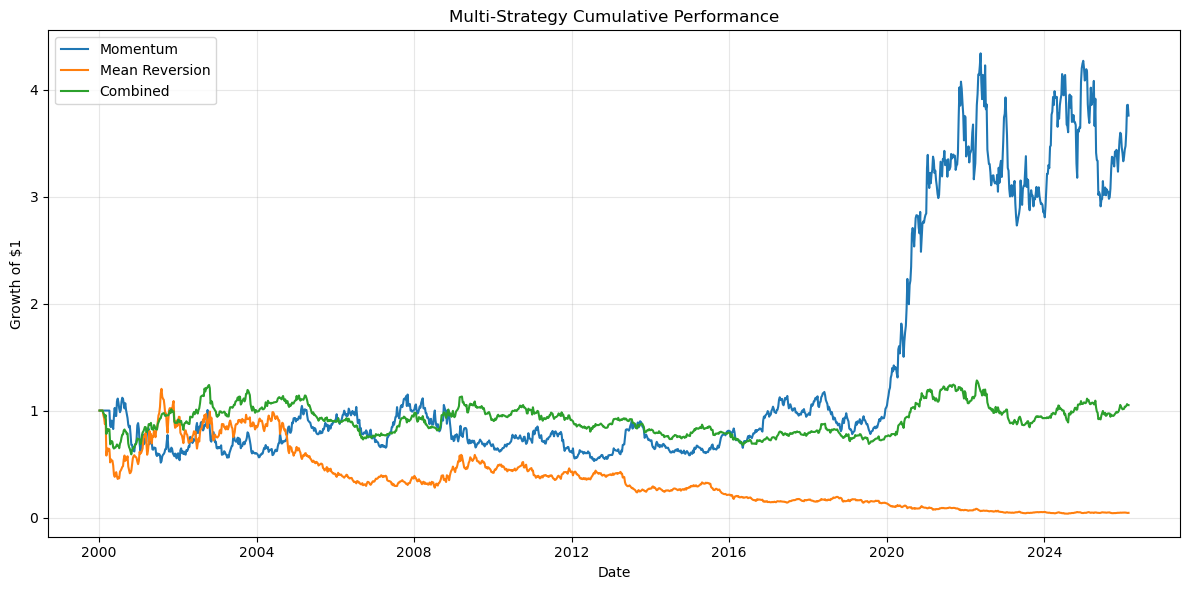

In [15]:
plt.figure(figsize=(12, 6))

for column in cumulative.columns:
    plt.plot(
        cumulative.index,
        cumulative[column],
        label=column
    )

plt.title("Multi-Strategy Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [16]:
drawdowns = pd.DataFrame(
    index=strategy_returns.index
)

returns_to_compare = strategy_returns.copy()
returns_to_compare["Combined"] = combined_returns

for column in returns_to_compare.columns:

    wealth = (
        1 + returns_to_compare[column].fillna(0)
    ).cumprod()

    peak = wealth.cummax()

    drawdowns[column] = (
        wealth / peak - 1
    )

drawdowns.tail()

,Momentum,Mean Reversion,Combined
Date,,,
2026-01-23,-0.199579,-0.961137,-0.190975
2026-01-30,-0.169282,-0.962155,-0.186256
2026-02-06,-0.111716,-0.963524,-0.172780
2026-02-13,-0.110846,-0.964151,-0.179488
2026-02-20,-0.134035,-0.963265,-0.180051


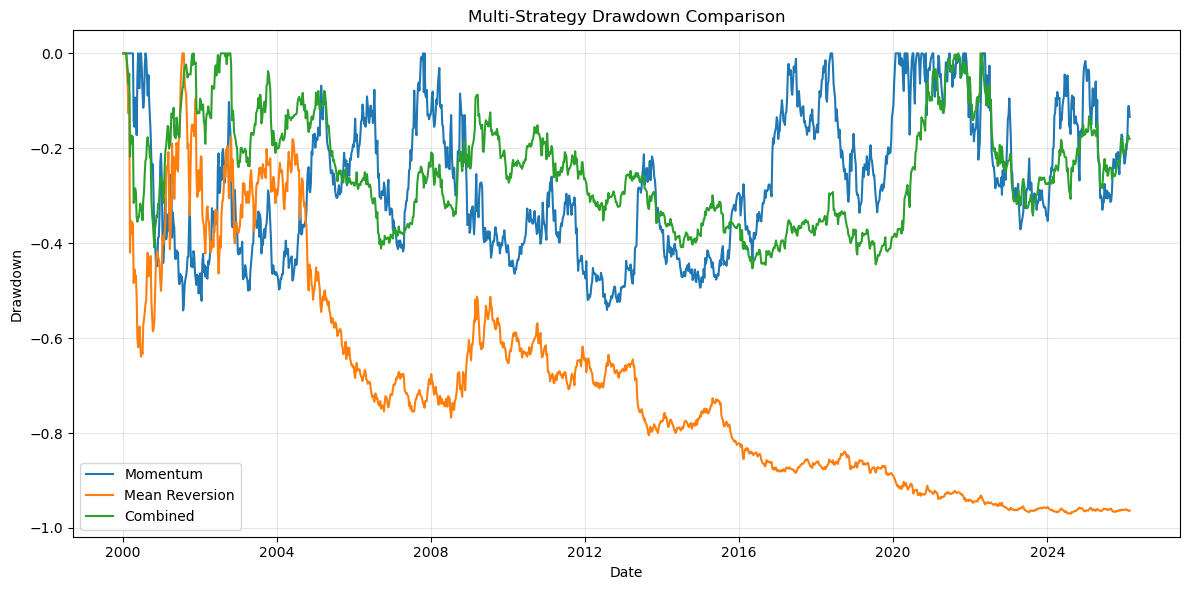

In [17]:
plt.figure(figsize=(12, 6))

for column in drawdowns.columns:
    plt.plot(
        drawdowns.index,
        drawdowns[column],
        label=column
    )

plt.title("Multi-Strategy Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [18]:
from pathlib import Path

results_dir = Path("../results")

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

strategy_returns.to_csv(
    results_dir / "multi_strategy_returns.csv"
)

combined_returns.to_csv(
    results_dir / "combined_strategy_returns.csv",
    header=True
)

performance_summary.to_csv(
    results_dir / "multi_strategy_performance.csv"
)

correlation.to_csv(
    results_dir / "strategy_correlation.csv"
)

print("Module 16 results saved successfully.")

Module 16 results saved successfully.
